In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 50.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 63.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 103.2 MB/s eta 0:00:0000:0100:01


In [2]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import itertools
     

# Constants
IMG_SIZE = 48
DATA_DIR = '/kaggle/input/facial-emotion-recognition/images'
EMOTIONS = ['Anger', 'Contempt', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprised']

# Load the dataset
csv_path = '/kaggle/input/facial-emotion-recognition/emotions.csv'
emotions_df = pd.read_csv(csv_path)
     

emotions_df['set_id'].unique()
     

# Encode the gender column
label_encoder = LabelEncoder()
emotions_df['gender'] = label_encoder.fit_transform(emotions_df['gender'])
     

emotions_df
# Function to load and preprocess images
def load_data():
    images = []
    labels = []

    for emotion_label, emotion in enumerate(EMOTIONS):
        # Get the directory for the current emotion
        emotion_dir = os.path.join(DATA_DIR, str(emotion_label))
        if os.path.isdir(emotion_dir):
            for img_file in os.listdir(emotion_dir):
                img_path = os.path.join(emotion_dir, img_file)
                img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img_resized = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                images.append(img_resized)
                labels.append(emotion_label)  # Assigning label based on index
        else:
            print(f"Directory not found for emotion {emotion}: {emotion_dir}")

    return np.array(images), np.array(labels)

# Load the data
images, labels = load_data()
     

# Define the number of samples for training and testing
n_train = 5000
n_test = 3000

# Load the data
images, labels = load_data()

# Normalize pixel values to be within 0 and 1
images = images / 255.0

# Reduce dataset size
train_images = images[:n_train]
train_labels = labels[:n_train]
test_images = images[-n_test:]
test_labels = labels[-n_test:]

# Add an extra dimension for convolutional input (e.g., grayscale channels)
train_images = np.expand_dims(train_images, axis=-1)  # Shape: (n_train, 48, 48, 1)
test_images = np.expand_dims(test_images, axis=-1)    # Shape: (n_test, 48, 48, 1)

# Convert labels to categorical
train_labels_categorical = to_categorical(train_labels, num_classes=len(EMOTIONS))
test_labels_categorical = to_categorical(test_labels, num_classes=len(EMOTIONS))

# Check the shapes of the processed data
print(f"Train images shape: {train_images.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Train labels shape: {train_labels_categorical.shape}")
print(f"Test labels shape: {test_labels_categorical.shape}")
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import RandomLayers
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
     

n_layers = 5    # Number of random layers


SAVE_PATH = ""  # Data saving folder
PREPROCESS = True           # If False, skip quantum processing and load data from SAVE_PATH
np.random.seed(0)           # Seed for NumPy random number generator
tf.random.set_seed(0)       # Seed for TensorFlow random number generator

2025-11-10 12:27:08.362567: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762777628.763772      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762777628.930251      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Train images shape: (64, 48, 48, 1)
Test images shape: (64, 48, 48, 1)
Train labels shape: (64, 8)
Test labels shape: (64, 8)



Running for 4 qubits...

Quantum circuit diagram:


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1762778255.939744      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762778255.940506      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/5


I0000 00:00:1762778258.814373     125 service.cc:148] XLA service 0x7cdfe800a990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762778258.815457     125 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1762778258.815477     125 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1762778259.087483     125 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1762778260.360560     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2/2 - 3s - 1s/step - accuracy: 0.1250 - loss: 2.2989 - val_accuracy: 0.6562 - val_loss: 1.4718
Epoch 2/5
2/2 - 0s - 36ms/step - accuracy: 0.5469 - loss: 1.4627 - val_accuracy: 0.9062 - val_loss: 1.0395
Epoch 3/5
2/2 - 0s - 34ms/step - accuracy: 0.7188 - loss: 1.1110 - val_accuracy: 0.9688 - val_loss: 0.7308
Epoch 4/5
2/2 - 0s - 34ms/step - accuracy: 0.7969 - loss: 0.7830 - val_accuracy: 0.9844 - val_loss: 0.4670
Epoch 5/5
2/2 - 0s - 34ms/step - accuracy: 0.9531 - loss: 0.5645 - val_accuracy: 0.9844 - val_loss: 0.3069
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step 

Classification Report:
              precision    recall  f1-score   support

       Anger       1.00      1.00      1.00         8
    Contempt       1.00      1.00      1.00         8
     Disgust       1.00      0.88      0.93         8
        Fear       1.00      1.00      1.00         8
       Happy       1.00      1.00      1.00         8
     Neutral       0.89      1.00      0.94         8
         Sad       1.00      1.00  

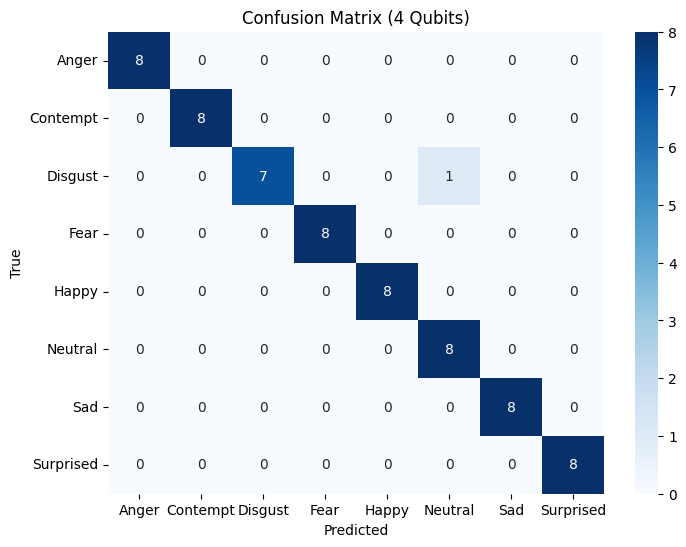

Test Accuracy: 0.9844


=== Summary of Results ===
4 Qubits: Accuracy = 0.9844


In [3]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import RandomLayers
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define qubit patch sizes
qubit_patch_shapes = {
    4: (2, 2),
    #6: (3, 2),
    #8: (4, 2),
    #10: (5, 2),
    #12: (4, 3),
}

n_epochs = 5

# Function to create circuit
def create_circuit(n_qubits, n_layers=3):
    dev = qml.device("default.qubit", wires=n_qubits)
    rand_params = np.random.uniform(high=2 * np.pi, size=(n_layers, n_qubits))

    @qml.qnode(dev)
    def circuit(phi):
        # Encoding pixels
        for j in range(n_qubits):
            qml.RY(np.pi * phi[j], wires=j)
        RandomLayers(rand_params, wires=range(n_qubits))
        return [qml.expval(qml.PauliZ(j)) for j in range(n_qubits)]

    return circuit, dev, rand_params

# Quantum convolution
def quanv(image, circuit, patch_h, patch_w):
    out_h = (image.shape[0] - patch_h) // 2 + 1
    out_w = (image.shape[1] - patch_w) // 2 + 1
    n_qubits = patch_h * patch_w
    out = np.zeros((out_h, out_w, n_qubits))

    for j in range(0, image.shape[0] - patch_h + 1, 2):
        for k in range(0, image.shape[1] - patch_w + 1, 2):
            patch_pixels = image[j:j+patch_h, k:k+patch_w, 0].flatten()
            q_results = circuit(patch_pixels)
            for c in range(n_qubits):
                out[j // 2, k // 2, c] = q_results[c]
    return out

# Training & Evaluation
def run_for_qubits(n_qubits):
    print(f"\nRunning for {n_qubits} qubits...")
    patch_h, patch_w = qubit_patch_shapes[n_qubits]
    circuit, dev, rand_params = create_circuit(n_qubits)

    # Show quantum circuit
    print("\nQuantum circuit diagram:")
    qml.draw(circuit)(np.random.rand(n_qubits))

    # Preprocess images
    q_train = np.array([quanv(img, circuit, patch_h, patch_w) for img in train_images])
    q_test = np.array([quanv(img, circuit, patch_h, patch_w) for img in test_images])

    # Build model
    model = keras.Sequential([
        keras.layers.Flatten(input_shape=q_train.shape[1:]),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(len(EMOTIONS), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train
    model.fit(q_train, train_labels, validation_data=(q_test, test_labels),
              epochs=n_epochs, batch_size=32, verbose=2)

    # Predictions
    y_pred = np.argmax(model.predict(q_test), axis=1)


    # Classification report
    print("\nClassification Report:")
    print(classification_report(test_labels, y_pred, target_names=EMOTIONS))

    # Confusion matrix
    cm = confusion_matrix(test_labels, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.title(f"Confusion Matrix ({n_qubits} Qubits)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # Test accuracy
    acc = model.evaluate(q_test, test_labels, verbose=0)[1]
    print(f"Test Accuracy: {acc:.4f}\n")

    return acc

# Run for 4,6,8,10,12 qubits
results = {}
for q in [4]:
    acc = run_for_qubits(q)
    results[q] = acc

print("\n=== Summary of Results ===")
for q, a in results.items():
    print(f"{q} Qubits: Accuracy = {a:.4f}")


=== Running experiment with random seed: 0 ===
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 - 2s - 811ms/step - accuracy: 0.1875 - loss: 2.1828 - val_accuracy: 0.7031 - val_loss: 1.3802
Epoch 2/5
2/2 - 0s - 37ms/step - accuracy: 0.6250 - loss: 1.3343 - val_accuracy: 0.9531 - val_loss: 0.9273
Epoch 3/5
2/2 - 0s - 34ms/step - accuracy: 0.6719 - loss: 1.0913 - val_accuracy: 0.9844 - val_loss: 0.5805
Epoch 4/5
2/2 - 0s - 33ms/step - accuracy: 0.9531 - loss: 0.6233 - val_accuracy: 0.9844 - val_loss: 0.3625
Epoch 5/5
2/2 - 0s - 36ms/step - accuracy: 0.9219 - loss: 0.5037 - val_accuracy: 0.9844 - val_loss: 0.2451
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step 

Classification Report:
              precision    recall  f1-score   support

       Anger       1.00      1.00      1.00         8
    Contempt       1.00      1.00      1.00         8
     Disgust       1.00      0.88      0.93         8
        Fear       1.00      1.00      1.00         8
       Happy       1.00      1.00      1.00         8
     Neutral       0.89      1.00      0.94         8
         Sad       1.00      1.0

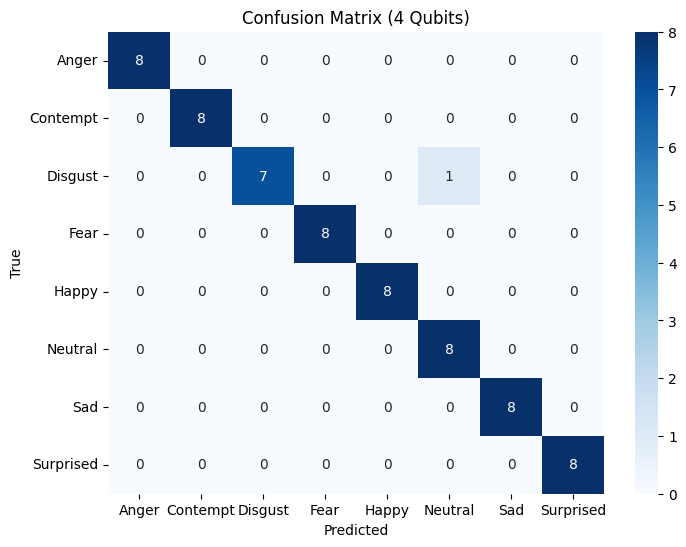


=== Running experiment with random seed: 1 ===
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 - 2s - 956ms/step - accuracy: 0.2500 - loss: 1.9507 - val_accuracy: 0.8750 - val_loss: 1.1961
Epoch 2/5
2/2 - 0s - 35ms/step - accuracy: 0.7031 - loss: 1.1822 - val_accuracy: 0.9844 - val_loss: 0.6581
Epoch 3/5
2/2 - 0s - 34ms/step - accuracy: 0.8281 - loss: 0.7379 - val_accuracy: 0.9844 - val_loss: 0.3423
Epoch 4/5
2/2 - 0s - 34ms/step - accuracy: 0.9375 - loss: 0.4218 - val_accuracy: 0.9844 - val_loss: 0.1780
Epoch 5/5
2/2 - 0s - 34ms/step - accuracy: 0.9531 - loss: 0.2387 - val_accuracy: 0.9844 - val_loss: 0.1009
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step 

Classification Report:
              precision    recall  f1-score   support

       Anger       1.00      1.00      1.00         8
    Contempt       1.00      1.00      1.00         8
     Disgust       1.00      0.88      0.93         8
        Fear       1.00      1.00      1.00         8
       Happy       1.00      1.00      1.00         8
     Neutral       0.89      1.00      0.94         8
         Sad       1.00      1.0

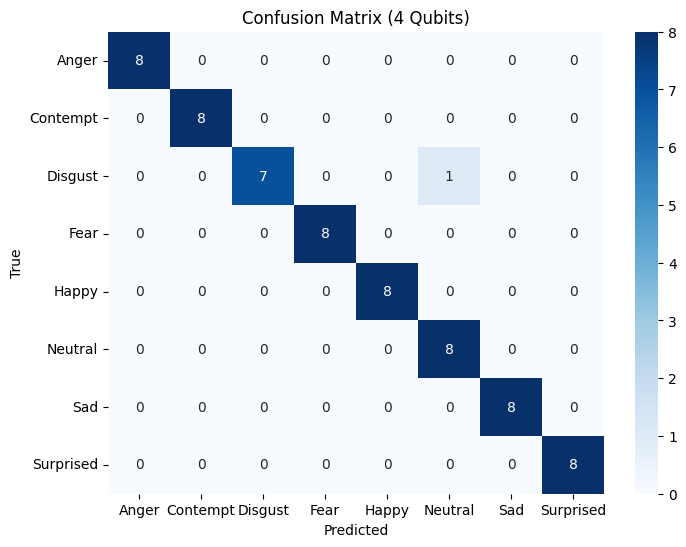


=== Running experiment with random seed: 2 ===
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 - 2s - 824ms/step - accuracy: 0.1875 - loss: 2.0444 - val_accuracy: 0.3594 - val_loss: 1.5450
Epoch 2/5
2/2 - 0s - 36ms/step - accuracy: 0.4531 - loss: 1.5001 - val_accuracy: 0.9062 - val_loss: 0.9414
Epoch 3/5
2/2 - 0s - 35ms/step - accuracy: 0.7188 - loss: 0.9302 - val_accuracy: 0.9688 - val_loss: 0.6484
Epoch 4/5
2/2 - 0s - 34ms/step - accuracy: 0.9062 - loss: 0.7560 - val_accuracy: 0.9844 - val_loss: 0.4210
Epoch 5/5
2/2 - 0s - 34ms/step - accuracy: 0.9062 - loss: 0.5932 - val_accuracy: 0.9844 - val_loss: 0.2779
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step 

Classification Report:
              precision    recall  f1-score   support

       Anger       1.00      1.00      1.00         8
    Contempt       1.00      1.00      1.00         8
     Disgust       1.00      0.88      0.93         8
        Fear       1.00      1.00      1.00         8
       Happy       1.00      1.00      1.00         8
     Neutral       0.89      1.00      0.94         8
         Sad       1.00      1.0

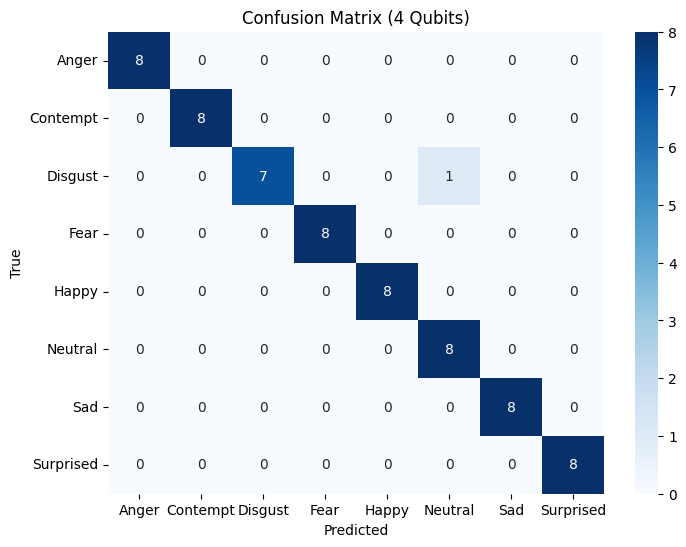


=== Running experiment with random seed: 3 ===
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 - 2s - 811ms/step - accuracy: 0.1562 - loss: 2.1003 - val_accuracy: 0.6562 - val_loss: 1.2976
Epoch 2/5
2/2 - 0s - 35ms/step - accuracy: 0.7344 - loss: 1.1572 - val_accuracy: 0.9688 - val_loss: 0.7191
Epoch 3/5
2/2 - 0s - 34ms/step - accuracy: 0.8750 - loss: 0.7365 - val_accuracy: 1.0000 - val_loss: 0.3869
Epoch 4/5
2/2 - 0s - 35ms/step - accuracy: 0.9062 - loss: 0.4186 - val_accuracy: 1.0000 - val_loss: 0.2067
Epoch 5/5
2/2 - 0s - 35ms/step - accuracy: 0.9844 - loss: 0.2872 - val_accuracy: 1.0000 - val_loss: 0.1102
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 

Classification Report:
              precision    recall  f1-score   support

       Anger       1.00      1.00      1.00         8
    Contempt       1.00      1.00      1.00         8
     Disgust       1.00      1.00      1.00         8
        Fear       1.00      1.00      1.00         8
       Happy       1.00      1.00      1.00         8
     Neutral       1.00      1.00      1.00         8
         Sad       1.00      1.0

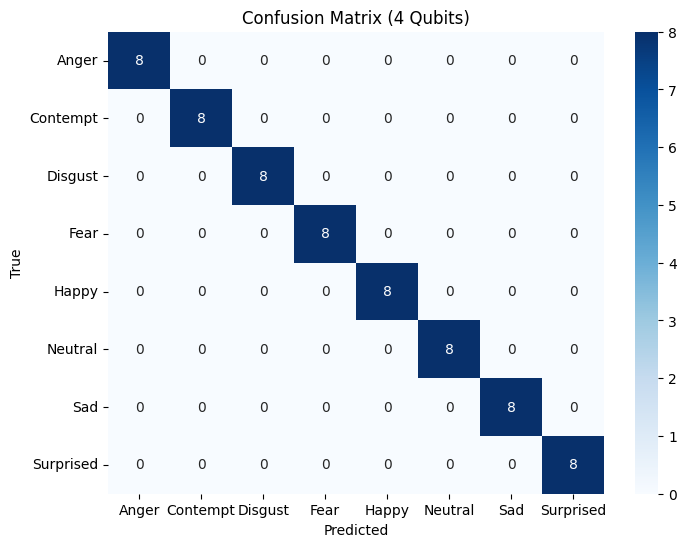


=== Running experiment with random seed: 4 ===
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 - 2s - 863ms/step - accuracy: 0.2812 - loss: 2.0467 - val_accuracy: 0.8125 - val_loss: 1.2109
Epoch 2/5
2/2 - 0s - 36ms/step - accuracy: 0.7969 - loss: 1.1558 - val_accuracy: 0.9844 - val_loss: 0.6492
Epoch 3/5
2/2 - 0s - 37ms/step - accuracy: 0.9531 - loss: 0.6573 - val_accuracy: 0.9844 - val_loss: 0.3157
Epoch 4/5
2/2 - 0s - 36ms/step - accuracy: 0.9688 - loss: 0.3291 - val_accuracy: 0.9844 - val_loss: 0.1502
Epoch 5/5
2/2 - 0s - 36ms/step - accuracy: 0.9844 - loss: 0.2171 - val_accuracy: 1.0000 - val_loss: 0.0730
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step 

Classification Report:
              precision    recall  f1-score   support

       Anger       1.00      1.00      1.00         8
    Contempt       1.00      1.00      1.00         8
     Disgust       1.00      1.00      1.00         8
        Fear       1.00      1.00      1.00         8
       Happy       1.00      1.00      1.00         8
     Neutral       1.00      1.00      1.00         8
         Sad       1.00      1.0

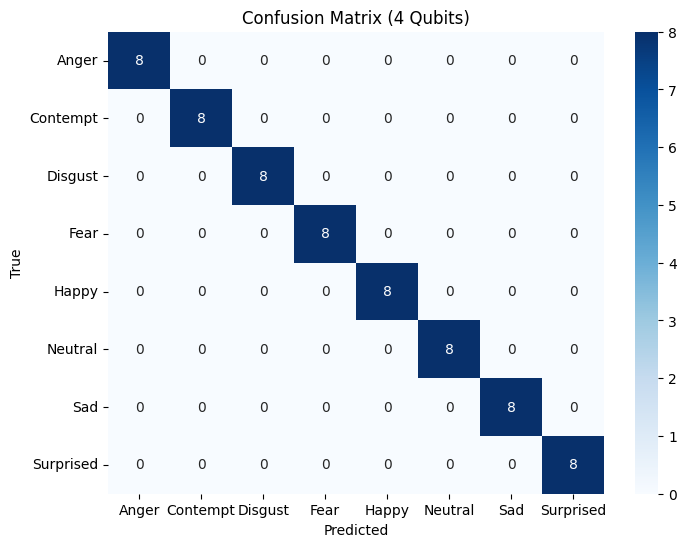

Quantum CNN (QCNN) Performance Summary

4 Qubits Results:
  Accuracy: 0.9906 ± 0.0077 (95% CI: [0.9800, 1.0013])
  AUC:      0.9994 ± 0.0011 (95% CI: [0.9979, 1.0010])


In [4]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane.templates import RandomLayers
import scipy.stats as st


qubit_patch_shapes = {4: (2, 2)}
n_epochs = 5
EMOTIONS = ['Anger', 'Contempt', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprised']


def create_circuit(n_qubits, n_layers=3):
    dev = qml.device("default.qubit", wires=n_qubits)
    rand_params = np.random.uniform(high=2*np.pi, size=(n_layers, n_qubits))

    @qml.qnode(dev)
    def circuit(phi):
        for j in range(n_qubits):
            qml.RY(np.pi * phi[j], wires=j)
        RandomLayers(rand_params, wires=range(n_qubits))
        return [qml.expval(qml.PauliZ(j)) for j in range(n_qubits)]
    return circuit

def quanv(image, circuit, patch_h, patch_w):
    out_h = (image.shape[0] - patch_h) // 2 + 1
    out_w = (image.shape[1] - patch_w) // 2 + 1
    n_qubits = patch_h * patch_w
    out = np.zeros((out_h, out_w, n_qubits))

    for j in range(0, image.shape[0]-patch_h+1, 2):
        for k in range(0, image.shape[1]-patch_w+1, 2):
            patch_pixels = image[j:j+patch_h, k:k+patch_w, 0].flatten()
            q_results = circuit(patch_pixels)
            out[j//2, k//2, :] = q_results
    return out

def run_for_qubits(n_qubits, train_images, train_labels, test_images, test_labels):
    patch_h, patch_w = qubit_patch_shapes[n_qubits]
    circuit = create_circuit(n_qubits)

    # Quantum feature maps
    q_train = np.array([quanv(img, circuit, patch_h, patch_w) for img in train_images])
    q_test = np.array([quanv(img, circuit, patch_h, patch_w) for img in test_images])

    # Build neural network
    model = keras.Sequential([
        keras.layers.Flatten(input_shape=q_train.shape[1:]),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(len(EMOTIONS), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train
    history = model.fit(q_train, train_labels,
                        validation_data=(q_test, test_labels),
                        epochs=n_epochs, batch_size=32, verbose=2)

    # Predictions
    y_pred_prob = model.predict(q_test)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # AUC
    test_labels_onehot = keras.utils.to_categorical(test_labels, num_classes=len(EMOTIONS))
    auc = roc_auc_score(test_labels_onehot, y_pred_prob, multi_class='ovr')

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(test_labels, y_pred, target_names=EMOTIONS))

    # Confusion Matrix
    cm = confusion_matrix(test_labels, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.title(f"Confusion Matrix ({n_qubits} Qubits)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # Accuracy
    acc = np.mean(y_pred == test_labels)
    return model, history, auc, acc, q_test


seeds = [0, 1, 2, 3, 4]
qubit_list = [4]

results_dict = {q: [] for q in qubit_list}
all_histories = {q: [] for q in qubit_list}
all_aucs = {q: [] for q in qubit_list}

for seed in seeds:
    print(f"\n=== Running experiment with random seed: {seed} ===")
    np.random.seed(seed)
    tf.random.set_seed(seed)

    for q in qubit_list:
        model, q_history, auc, acc, q_test = run_for_qubits(q, train_images, train_labels, test_images, test_labels)
        results_dict[q].append(acc)
        all_histories[q].append(q_history)
        all_aucs[q].append(auc)

# Save last history for plotting
q_history = all_histories[4][-1]


print("Quantum CNN (QCNN) Performance Summary")

for q in qubit_list:
    acc_list = results_dict[q]
    auc_list = all_aucs[q]

    mean_acc = np.mean(acc_list)
    std_acc = np.std(acc_list)
    mean_auc = np.mean(auc_list)
    std_auc = np.std(auc_list)

    ci_acc = st.t.interval(0.95, len(acc_list)-1, loc=mean_acc, scale=st.sem(acc_list))
    ci_auc = st.t.interval(0.95, len(auc_list)-1, loc=mean_auc, scale=st.sem(auc_list))

    print(f"\n{q} Qubits Results:")
    print(f"  Accuracy: {mean_acc:.4f} ± {std_acc:.4f} (95% CI: [{ci_acc[0]:.4f}, {ci_acc[1]:.4f}])")
    print(f"  AUC:      {mean_auc:.4f} ± {std_auc:.4f} (95% CI: [{ci_auc[0]:.4f}, {ci_auc[1]:.4f}])")


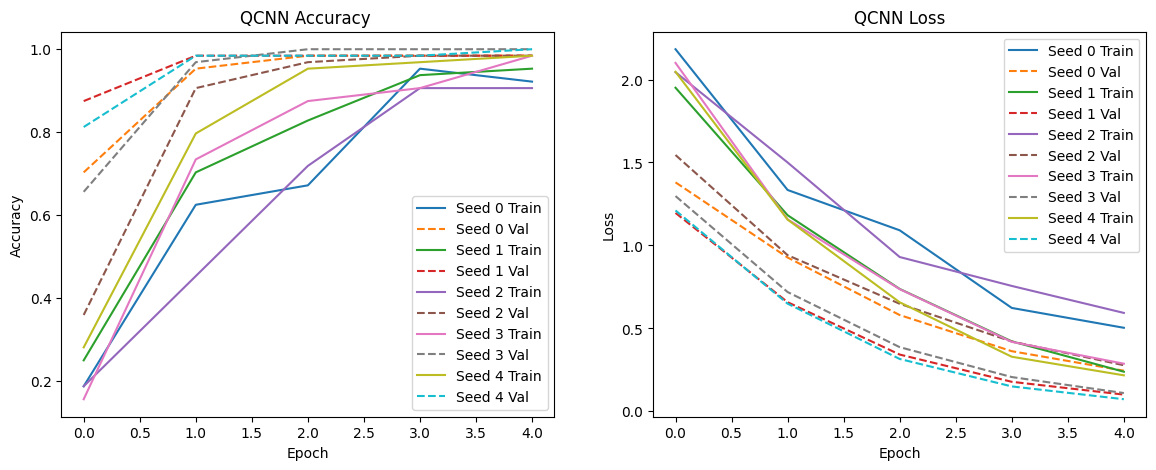

In [5]:
for q in qubit_list:
    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    for i, history in enumerate(all_histories[q]):
        plt.plot(history.history['accuracy'], label=f'Seed {seeds[i]} Train')
        plt.plot(history.history['val_accuracy'], '--', label=f'Seed {seeds[i]} Val')
    plt.title(f"QCNN Accuracy ")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    for i, history in enumerate(all_histories[q]):
        plt.plot(history.history['loss'], label=f'Seed {seeds[i]} Train')
        plt.plot(history.history['val_loss'], '--', label=f'Seed {seeds[i]} Val')
    plt.title(f"QCNN Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [6]:
import scipy.stats as st 
for q in qubit_list: 
    acc_list = results_dict[q] 
    mean_acc = np.mean(acc_list) 
    ci = st.t.interval(0.95, len(acc_list)-1, loc=mean_acc, scale=st.sem(acc_list)) 
    print(f"{q} Qubits: Mean Accuracy = {mean_acc:.4f}, 95% CI = [{ci[0]:.4f}, {ci[1]:.4f}]")

4 Qubits: Mean Accuracy = 0.9906, 95% CI = [0.9800, 1.0013]


In [7]:
for q in qubit_list:
    auc_list = all_aucs[q]
    mean_auc = np.mean(auc_list)
    ci = st.t.interval(0.95, df=len(auc_list)-1, loc=mean_auc, scale=st.sem(auc_list))
    print(f"{q} Qubits: Mean AUC = {mean_auc:.4f}, 95% CI = [{ci[0]:.4f}, {ci[1]:.4f}]")

4 Qubits: Mean AUC = 0.9994, 95% CI = [0.9979, 1.0010]


Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 - 5s - 3s/step - accuracy: 0.1250 - loss: 2.0881 - val_accuracy: 0.5469 - val_loss: 1.9662
Epoch 2/5
2/2 - 0s - 38ms/step - accuracy: 0.2812 - loss: 1.9196 - val_accuracy: 0.5469 - val_loss: 1.8078
Epoch 3/5
2/2 - 0s - 38ms/step - accuracy: 0.4531 - loss: 1.8030 - val_accuracy: 0.8594 - val_loss: 1.6220
Epoch 4/5
2/2 - 0s - 39ms/step - accuracy: 0.5469 - loss: 1.6846 - val_accuracy: 0.9688 - val_loss: 1.3977
Epoch 5/5
2/2 - 0s - 40ms/step - accuracy: 0.6406 - loss: 1.4338 - val_accuracy: 0.8438 - val_loss: 1.1459

Test Accuracy: 0.8438
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step 

Classification Report:
              precision    recall  f1-score   support

       Anger       1.00      1.00      1.00         8
    Contempt       1.00      1.00      1.00         8
     Disgust       1.00      0.88      0.93         8
        Fear       1.00      0.88      0.93         8
       Happy       1.00      1.00      1.00         8
     Neutral       0.00      0.00      0.00         8
         Sad

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


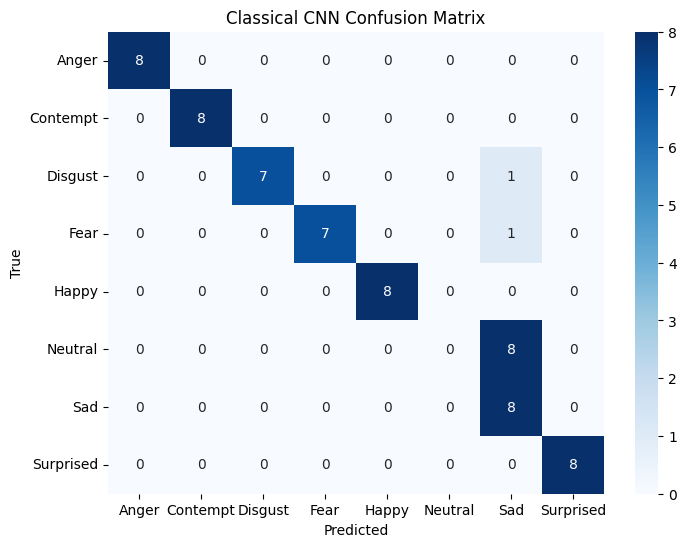

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


train_labels_cat = to_categorical(train_labels, num_classes=len(EMOTIONS))
test_labels_cat = to_categorical(test_labels, num_classes=len(EMOTIONS))

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(EMOTIONS), activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = cnn_model.fit(train_images, train_labels_cat, 
                        validation_data=(test_images, test_labels_cat),
                        epochs=5, batch_size=32, verbose=2)

# Evaluate
test_loss, test_acc = cnn_model.evaluate(test_images, test_labels_cat, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Predictions
y_pred = np.argmax(cnn_model.predict(test_images), axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(test_labels, y_pred, target_names=EMOTIONS))

# Confusion matrix
cm = confusion_matrix(test_labels, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=EMOTIONS, yticklabels=EMOTIONS)
plt.title("Classical CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

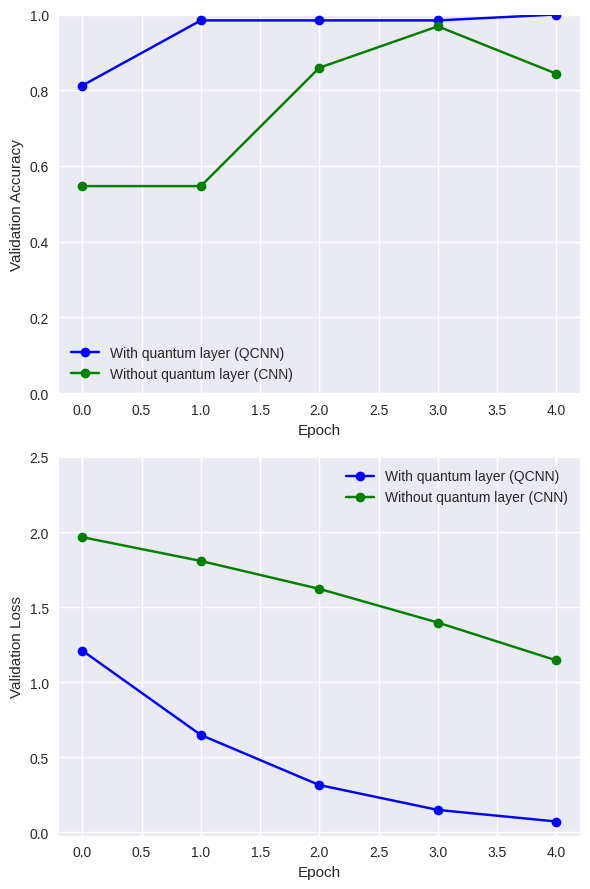

In [11]:
q_history = all_histories[qubit_list[0]][-1]

c_history=history

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 9))

# Plot validation accuracy
ax1.plot(q_history.history["val_accuracy"], "-ob", label="With quantum layer (QCNN)")
ax1.plot(c_history.history["val_accuracy"], "-og", label="Without quantum layer (CNN)")
ax1.set_ylabel("Validation Accuracy")
ax1.set_ylim([0, 1])
ax1.set_xlabel("Epoch")
ax1.legend()

# Plot validation loss
ax2.plot(q_history.history["val_loss"], "-ob", label="With quantum layer (QCNN)")
ax2.plot(c_history.history["val_loss"], "-og", label="Without quantum layer (CNN)")
ax2.set_ylabel("Validation Loss")
ax2.set_ylim(top=2.5)
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()